This notebook borrows from

https://github.com/VincentStimper/normalizing-flows/blob/master/examples/neural_spline_flow.ipynb 

in order to test if using splines is better than realnvp

In [1]:
# Import required packages
import torch
import numpy as np
import normflows as nf\

from matplotlib import pyplot as plt

from tqdm import tqdm

from flonacomldft.utils.io_utils import load_pickle_file, load_csv_file
from flonacomldft.sampling import run_metropolis
from flonacomldft.utils.diagnostics import get_ESS
from flonacomldft.models.mixture import Mixture, get_models
from flonacomldft.internal_coordinates import Coordinates_mapping, join_data

from flonacomldft.train_flow_from_data import get_ratio_acc
from flonacomldft.free_energy_computations import (
    compute_TFP_logratio, compute_deepBAR_logratio,
    compute_TFP, compute_BAR
)

import copy 

def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

In [4]:
# Define flows
# number of?
K = 16
torch.manual_seed(0)

latent_size = 12
hidden_units = 128
hidden_layers = 2


flows = []
for i in range(K):
    flows += [nf.flows.AutoregressiveRationalQuadraticSpline(latent_size, hidden_layers, hidden_units)]
    flows += [nf.flows.LULinearPermute(latent_size)]

# Set prior and q0
q0 = nf.distributions.DiagGaussian(12, trainable=False)
    
# Construct flow model
nfm = nf.NormalizingFlow(q0=q0, flows=flows)

# Move model on GPU if available
enable_cuda = True
device = torch.device('cuda' if torch.cuda.is_available() and enable_cuda else 'cpu')
nfm = nfm.to(device)

In [5]:
nfm.log_prob(torch.randn(1, 12).to(device))

tensor([-15.5827], grad_fn=<AddBackward0>)

# Loading MD data

In [2]:
coord_mapping = Coordinates_mapping() 
T = 300
kb = 8.617333262e-5

mode_labels = [0, 1]
dataset_label = 'md_train'
# dataset_labels = ['md_train', 'md_test', 'flow_train', 'flow_test']

zmats = []
xs = []
for mode_label in mode_labels:
    file='datasets/is{:d}_{:s}.csv'.format(mode_label, dataset_label)
    zmat = load_csv_file(file)
    
    x, logdetjac, energies = coord_mapping.get_real_centered_from_internal(zmat[:, :12], 
                                                                        zmat[:, 14],  
                                                                        isomer=mode_label,
                                                                        energies=zmat[:, 12])
    x = join_data(x, energies, zmat[:, 13], logdetjac,)
    
    zmats.append(zmat)
    xs.append(x)

xs = torch.cat(xs)
x_mds = xs

/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_co

In [7]:
x_mds.shape




torch.Size([8000, 15])

In [3]:
mode_labels = [0, 1]
flows_dic = [load_pickle_file('models/is{:d}_flow_dic_training.pkl'.format(mode_label)) for mode_label in mode_labels]
mlps_dic = [load_pickle_file('models/is{:d}_mlp_dic_training.pkl'.format(mode_label)) for mode_label in mode_labels]

# trained
flows = get_models(flows_dic)
mlps = get_models(mlps_dic)

In [4]:
def get_ratio_acc_rqs(nfm, init, n_chains, mlp_model, T=300):
    
    assert init.shape[0] == n_chains

    kb = 8.617333262e-5
    beta = 1 / (kb * T)

    x_init = init[:, :12]
    u_init = init[:, 12]
    isomer_init = init[:, 13]

    x_new, _ = nfm.sample(n_chains)
    isomer_new = isomer_init

    x_new = x_new.clone().detach().float()
    isomer_new = isomer_new.clone().detach().float()

    nll_x = - nfm.log_prob(x_new)
    nll_x_init = - nfm.log_prob(x_init)

    u_new = torch.zeros((n_chains, 1))
    u_new = mlp_model(x_new)
    u_new = u_new.squeeze().float()

    ratio = -beta * u_new + nll_x
    ratio += beta * u_init - nll_x_init
    ratio = torch.exp(ratio)

    return torch.minimum(torch.ones_like(ratio), ratio).detach().cpu().numpy()

# Training Flows

In [10]:
# Train model
max_iter = 200 #00
# num_samples = 2 ** 9
report_split = 10

mode_label = 0

x = (x_mds[x_mds[:, 13] == mode_label]).float().to(device)
x_train = x[:3750]
x_train = x_train[:, :12].detach()
x_test = x[3750:]

losses = np.array([])
test_losses = np.array([])
accs = np.array([])
models = [copy.deepcopy(nfm)]

optimizer = torch.optim.Adam(nfm.parameters(), lr=1e-3, weight_decay=1e-5)

for it in tqdm(range(max_iter)):
    optimizer.zero_grad()

    # Compute loss
    loss = nfm.forward_kld(x_train)
    
    # Do backprop and optimizer step
    if ~(torch.isnan(loss) | torch.isinf(loss)):
        loss.backward()
        optimizer.step()
    
    # Log loss
    losses = np.append(losses, loss.to('cpu').data.numpy())

    if (it + 1) % int(max_iter / report_split) == 0:
        nfm.eval()
        test_losses = np.append(test_losses, nfm.forward_kld(x_test[:,:12]).to('cpu').data.numpy())
        accs = np.append(accs, get_ratio_acc_rqs(nfm, x_test, x_test.shape[0], mlps[mode_label], T=300).mean())
        models.append(copy.deepcopy(nfm))
        nfm.train()
    
    # Plot learned distribution
    # if (it + 1) % show_iter == 0:
    #     nfm.eval()
    #     log_prob = nfm.log_prob(zz)
    #     nfm.train()
    #     prob = torch.exp(log_prob.to('cpu').view(*xx.shape))
    #     prob[torch.isnan(prob)] = 0

    #     plt.figure(figsize=(15, 15))
    #     plt.pcolormesh(xx, yy, prob.data.numpy())
    #     plt.gca().set_aspect('equal', 'box')
    #     plt.show()


100%|██████████| 200/200 [15:47<00:00,  4.74s/it]


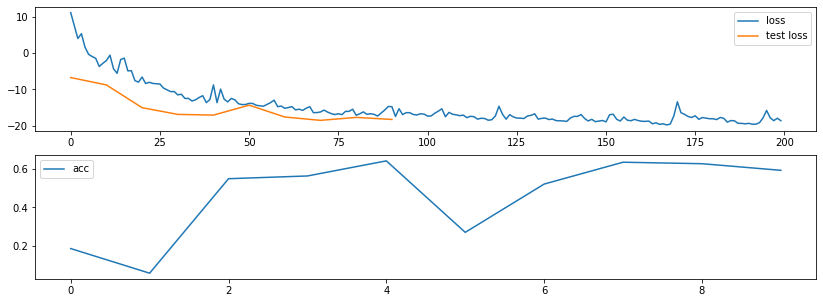

In [11]:
plt.figure(figsize=(14, 5))
axes = [plt.subplot(2, 1, i + 1) for i in range(2)]
plt.sca(axes[0])
plt.plot(losses, label='loss')
plt.plot(np.arange(len(test_losses)) * report_split, test_losses, label='test loss')
plt.legend()

plt.sca(axes[1])
plt.plot(accs, label='acc')
plt.legend()
plt.show()

# Equilibrating the MCMCs

In [21]:
def run_metropolis_rqs(model,
    init,
    n_chains,
    n_steps,
    mlp_model,
    T=300,
    with_tqdm=False,
):
    assert init.shape[0] == n_chains

    x_init = init[:, :12]
    u_init = init[:, 12]
    isomer_init = init[:, 13]

    beta = 1 / (kb * T)

    xs = []
    us = []
    accs = []
    ratios = []
    nlls = []

    pbar = tqdm(range(n_steps))

    for dt in pbar:
        x_new, _ = model.sample(n_chains)
        isomer_new = isomer_init

        x_new = x_new.clone().detach().float()
        isomer_new = isomer_new.clone().detach().float()

        nll_x = - model.log_prob(x_new)
        nll_x_init = - model.log_prob(x_init)
       
        u_new = mlp_model(x_new).squeeze().float()

        ratio = -beta * u_new + nll_x
        ratio += beta * u_init - nll_x_init
        ratio = torch.exp(ratio)
        u = torch.rand_like(ratio)
        ratio = torch.min(ratio, torch.ones_like(ratio))

        acc = u < torch.min(ratio, torch.ones_like(ratio))

        x_new[~acc] = x_init[~acc]
        u_new[~acc] = u_init[~acc]

        isomer_new = isomer_init

        xs.append(x_new.float().clone())
        us.append(u_new.float().clone())
        accs.append(acc.float().clone())
        nlls.append(nll_x.float().clone())
        ratios.append(ratio.mean().float().clone())

        x_init = x_new.clone().detach()
        u_init = u_new.clone().detach()
        isomer_init = isomer_new.clone().detach()

        if with_tqdm:
            pbar.set_description(f'acc: {ratio.mean().item() :.2f}')

    return torch.stack(xs), torch.stack(us), torch.stack(accs), torch.stack(nlls), torch.stack(ratios)

In [3]:
mode_label = 0
n_steps = 100
n_chains = 100

mcmc_runs = []
for m,model in enumerate(models[::2]):
    x_init = x_test[:n_chains]
    mcmc_run = run_metropolis_rqs(models[m], x_init, x_init.shape[0], n_steps, mlps[mode_label], T=300, with_tqdm=True)
    mcmc_runs.append(mcmc_run)
    


NameError: name 'models' is not defined

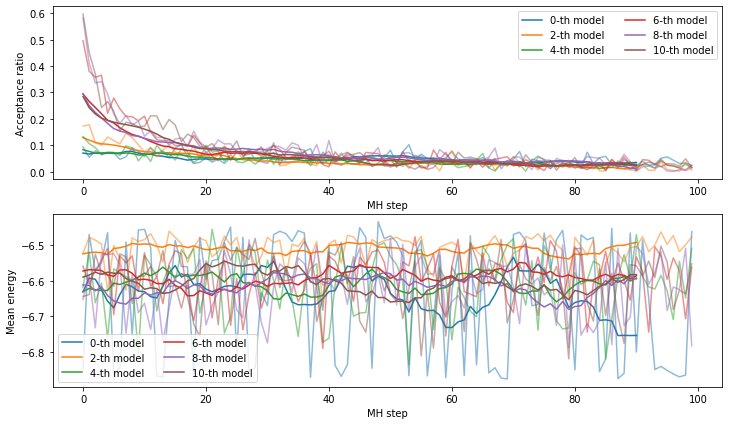

In [23]:
plt.figure(figsize=(12,7))
axes = [plt.subplot(2, 1, i + 1) for i in range(2)]
for m,mcmc_run in enumerate(mcmc_runs):
    
    xs, us, accs, nlls, ratios = mcmc_run
    plt.sca(axes[0])
    _ = plt.plot(ratios.detach().numpy(), alpha=0.5)
    plt.plot(moving_average(ratios.detach().numpy(), 10), c=_[0].get_color(), label='{:d}-th model'.format(2 * m))
    plt.xlabel('MH step')
    plt.ylabel('Acceptance ratio')
    plt.legend(ncol=2)

    plt.sca(axes[1]) 
    _ = plt.plot(us.mean(0).detach().numpy(), alpha=0.5)
    plt.plot(moving_average(us.mean(0).detach().numpy(), 10), c=_[0].get_color(), label='{:d}-th model'.format(2* m))
    plt.xlabel('MH step')
    plt.ylabel('Mean energy')
    plt.legend(ncol=2)


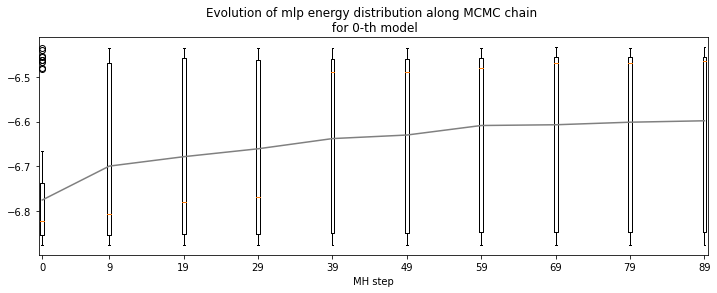

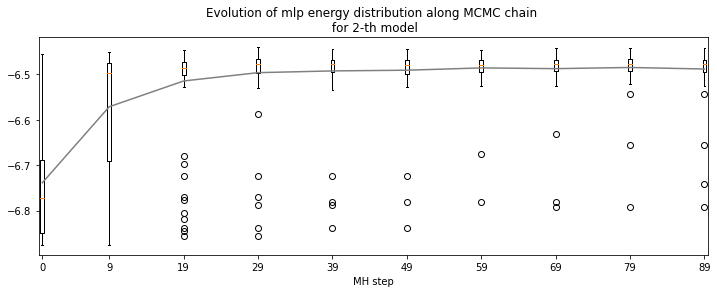

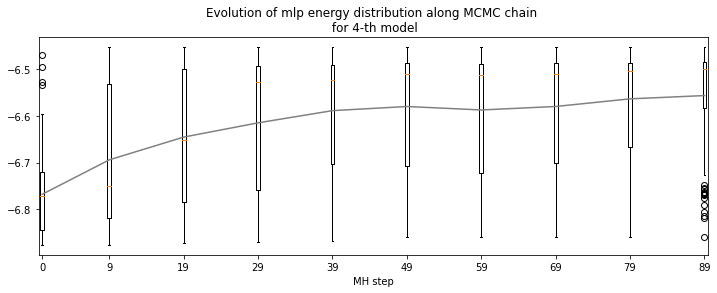

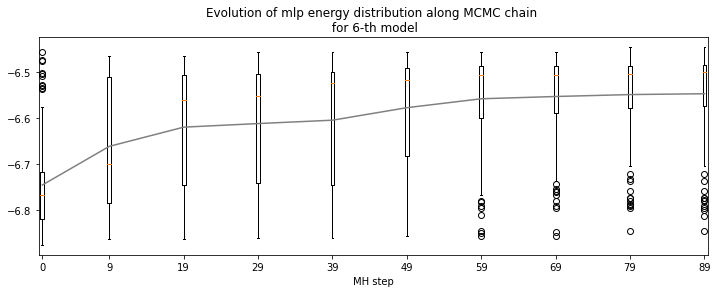

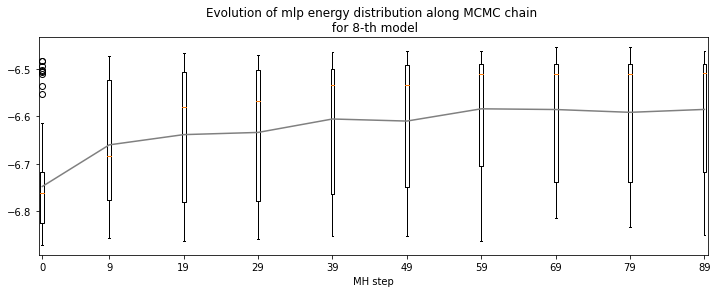

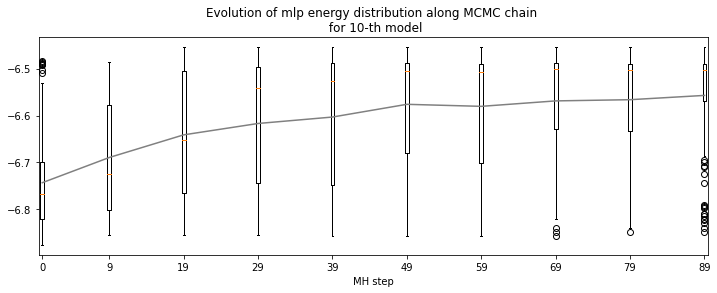

In [24]:
for m,mcmc_run in enumerate(mcmc_runs):
    xs, us, accs, nlls, ratios = mcmc_run
    plt.figure(figsize=(12,4))
    steps = np.maximum(0, np.arange(10) * 10 - 1)
    plt.boxplot([us[step, :].detach().numpy() for step in steps], positions=steps)
    plt.plot(steps, [us[step, :].detach().numpy().mean() for step in steps], '-', c='grey')
    plt.title('Evolution of mlp energy distribution along MCMC chain \n for {:d}-th model'.format(2 * m))
    plt.xlabel('MH step') 

# Looking the disctributions of flow and mlp energies 

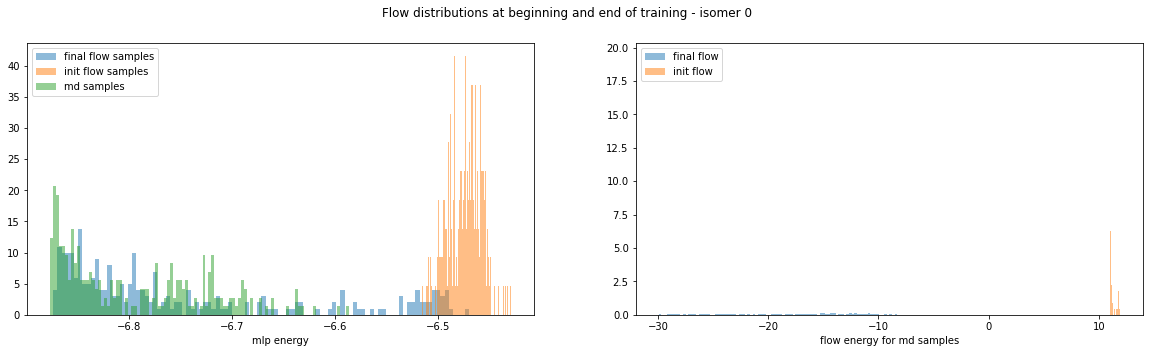

In [31]:
mode_label = 0

init_flow = models[0]
final_flow = models[-1]

n_chains = x_test.shape[0]

plt.figure(figsize=(20,5))
plt.suptitle('Flow distributions at beginning and end of training - isomer {:d}'.format(mode_label))
xs_flow_init, _ = init_flow.sample(n_chains)
xs_flow_final, _ = final_flow.sample(n_chains)
ax = plt.subplot(1,2,1)
plt.hist(mlps[mode_label](xs_flow_final).detach().numpy(), bins=100, alpha=0.5, density=True, label='final flow samples')
plt.hist(mlps[mode_label](xs_flow_init).detach().numpy(), bins=100, alpha=0.5, density=True, label='init flow samples')
plt.hist(mlps[mode_label](x_test[:,:12]).detach().numpy(), bins=100, alpha=0.5, density=True, label='md samples')
plt.xlabel('mlp energy')
plt.legend()
ax = plt.subplot(1,2,2)
plt.hist(- final_flow.log_prob(x_test[:,:12]).detach().numpy(), bins=100, alpha=0.5, density=True, label='final flow')
plt.hist(- init_flow.log_prob(x_test[:,:12]).detach().numpy(), bins=100, alpha=0.5, density=True, label='init flow')
plt.xlabel('flow energy for md samples')
plt.legend()

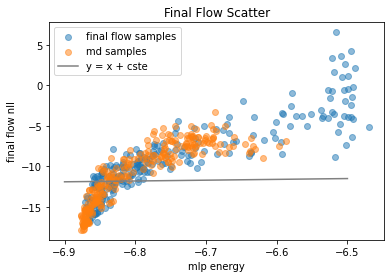

In [48]:
kb = 0.0019872041
T = 300
beta = 1 / (kb * T)

plt.title('Final Flow Scatter')
plt.scatter(mlps[mode_label](xs_flow_final).detach().numpy(), - final_flow.log_prob(xs_flow_final).detach().numpy()/beta, alpha=0.5, label='final flow samples')
plt.scatter(mlps[mode_label](x_test[:,:12]).detach().numpy(), - final_flow.log_prob(x_test[:,:12]).detach().numpy()/beta, alpha=0.5, label='md samples')
plt.plot(np.arange(-6.9, -6.5, 0.01), np.arange(-6.9, -6.5, 0.01) - 5 , c='grey', label='y = x + cste')
plt.ylabel('final flow nll')
plt.xlabel('mlp energy')
plt.legend()

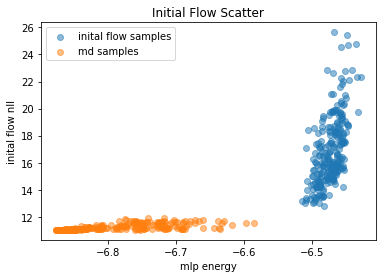

In [52]:
plt.title('Initial Flow Scatter')
plt.scatter(mlps[mode_label](xs_flow_init).detach().numpy(), - init_flow.log_prob(xs_flow_init).detach().numpy(), alpha=0.5, label='inital flow samples')
plt.scatter(mlps[mode_label](x_test[:,:12]).detach().numpy(), - init_flow.log_prob(x_test[:,:12]).detach().numpy(), alpha=0.5, label='md samples')
plt.ylabel('inital flow nll')
plt.xlabel('mlp energy')
plt.legend()

In [ ]:
# for m,mcmc_run in enumerate(mcmc_runs):
#     xs, us, accs, nlls, ratios = mcmc_run
#     plt.figure(figsize=(12,4))
#     steps = np.maximum(0, np.arange(10) * 10 - 1)
#     plt.boxplot([us[step, :].detach().numpy() for step in steps], positions=steps)
#     plt.plot(steps, [us[step, :].detach().numpy().mean() for step in steps], '-', c='grey')
#     plt.title('Evolution of mlp energy distribution along MCMC chain \n for {:d}-th model'.format(2 * m))
#     plt.xlabel('MH step') 

In [2]:
xs.shape

NameError: name 'xs' is not defined

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


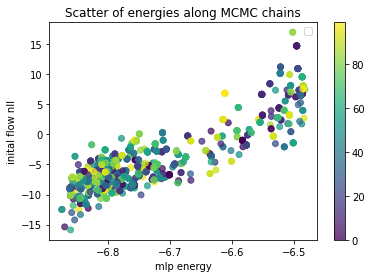

In [66]:
plt.title('Scatter of energies along MCMC chains')
steps = 100
for chain in range(10):
    # plt.plot(mlps[mode_label](xs[chain][:steps]).detach().numpy(), - final_flow.log_prob(xs[chain][:steps]).detach().numpy()/beta, '-', alpha=0.5, label='inital flow samples')
    plt.scatter(mlps[mode_label](xs[:steps, chain, :]).detach().numpy(), - final_flow.log_prob(xs[:steps, chain, :]).detach().numpy()/beta,  c=np.arange(steps), cmap='viridis', alpha=0.75)
plt.colorbar()
# plt.plot(mlps[mode_label](x_test[:,:12]).detach().numpy(), - init_flow.log_prob(x_test[:,:12]).detach().numpy(), alpha=0.5, label='md samples')
plt.ylabel('inital flow nll')
plt.xlabel('mlp energy')
plt.legend()

# Trying to train longer

In [17]:
# Define flows
# number of?
K = 16
torch.manual_seed(0)

latent_size = 12
hidden_units = 128
hidden_layers = 2

flows = []
for i in range(K):
    flows += [nf.flows.AutoregressiveRationalQuadraticSpline(latent_size, hidden_layers, hidden_units)]
    flows += [nf.flows.LULinearPermute(latent_size)]

# Set prior and q0
q0 = nf.distributions.DiagGaussian(12, trainable=False)
    
# Construct flow model
nfm = nf.NormalizingFlow(q0=q0, flows=flows)

# Move model on GPU if available
enable_cuda = True
device = torch.device('cuda' if torch.cuda.is_available() and enable_cuda else 'cpu')
nfm = nfm.to(device)

In [18]:
# Train model
max_iter = 500 #00 #00
# num_samples = 2 ** 9
report_split = 10

mode_label = 0

x = (x_mds[x_mds[:, 13] == mode_label]).float().to(device)
x_train = x[:3750]
x_train = x_train[:, :12].detach()
x_test = x[3750:]

losses = np.array([])
test_losses = np.array([])
accs = np.array([])
models = [copy.deepcopy(nfm)]

optimizer = torch.optim.Adam(nfm.parameters(), lr=1e-3, weight_decay=1e-5)

for it in tqdm(range(max_iter)):
    optimizer.zero_grad()

    # Compute loss
    loss = nfm.forward_kld(x_train)
    
    # Do backprop and optimizer step
    if ~(torch.isnan(loss) | torch.isinf(loss)):
        loss.backward()
        optimizer.step()
    
    # Log loss
    losses = np.append(losses, loss.to('cpu').data.numpy())

    if (it + 1) % int(max_iter / report_split) == 0:
        nfm.eval()
        test_losses = np.append(test_losses, nfm.forward_kld(x_test[:,:12]).to('cpu').data.numpy())
        accs = np.append(accs, get_ratio_acc_rqs(nfm, x_test, x_test.shape[0], mlps[mode_label], T=300).mean())
        models.append(copy.deepcopy(nfm))
        nfm.train()
    
    # Plot learned distribution
    # if (it + 1) % show_iter == 0:
    #     nfm.eval()
    #     log_prob = nfm.log_prob(zz)
    #     nfm.train()
    #     prob = torch.exp(log_prob.to('cpu').view(*xx.shape))
    #     prob[torch.isnan(prob)] = 0

    #     plt.figure(figsize=(15, 15))
    #     plt.pcolormesh(xx, yy, prob.data.numpy())
    #     plt.gca().set_aspect('equal', 'box')
    #     plt.show()


100%|██████████| 500/500 [26:05<00:00,  3.13s/it] 


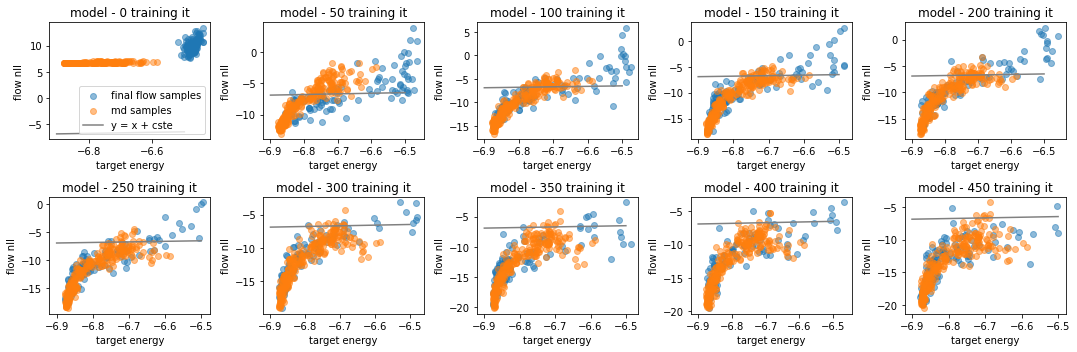

In [19]:
T = 300
kb = 0.0019872041
beta = 1 / (kb * T)

plt.figure(figsize=(15,5))
axes = [plt.subplot(2, 5, i + 1) for i in range(10)]
# plt.suptitle('Samples from models projected on first two dimensions')
for m,model in enumerate(models[:10]):
    model.eval()
    plt.sca(axes[m])
    final_flow = models[m]
    xs_flow_final, _ = final_flow.sample(100)

    plt.title('model - {:d} training it'.format(int(m * max_iter / report_split)))
    plt.scatter(mlps[mode_label](xs_flow_final).detach().numpy(), - final_flow.log_prob(xs_flow_final).detach().numpy()/beta, alpha=0.5, label='final flow samples')
    plt.scatter(mlps[mode_label](x_test[:,:12]).detach().numpy(), - final_flow.log_prob(x_test[:,:12]).detach().numpy()/beta, alpha=0.5, label='md samples')
    plt.plot(np.arange(-6.9, -6.5, 0.01), np.arange(-6.9, -6.5, 0.01) , c='grey', label='y = x + cste')
    plt.ylabel('flow nll')
    plt.xlabel('target energy')

    if m == 0:
        plt.legend()
plt.tight_layout()
plt.show()

In [22]:
mode_label = 0
n_steps = 100
n_chains = 100

mcmc_runs = []
for m,model in enumerate(models[::2]):
    x_init = x_test[:n_chains]
    mcmc_run = run_metropolis_rqs(models[m], x_init, x_init.shape[0], n_steps, mlps[mode_label], T=300, with_tqdm=True)
    mcmc_runs.append(mcmc_run)
    


acc: 0.01: 100%|██████████| 100/100 [02:22<00:00,  1.43s/it]


In [1]:
plt.figure(figsize=(12,7))
axes = [plt.subplot(2, 1, i + 1) for i in range(2)]
for m,mcmc_run in enumerate(mcmc_runs):
    
    xs, us, accs, nlls, ratios = mcmc_run
    plt.sca(axes[0])
    _ = plt.plot(ratios.detach().numpy(), alpha=0.5)
    plt.plot(moving_average(ratios.detach().numpy(), 10), c=_[0].get_color(), label='{:d}-th model'.format(2 * m))
    plt.xlabel('MH step')
    plt.ylabel('Acceptance ratio')
    plt.legend(ncol=2)

    plt.sca(axes[1]) 
    _ = plt.plot(us.mean(0).detach().numpy(), alpha=0.5)
    plt.plot(moving_average(us.mean(0).detach().numpy(), 10), c=_[0].get_color(), label='{:d}-th model'.format(2* m))
    plt.xlabel('MH step')
    plt.ylabel('Mean energy')
    plt.legend(ncol=2)


NameError: name 'plt' is not defined